**Image Generation with Autoencoders**

In [2]:
import torchvision
import torchvision.transforms as T

transform=T.Compose([
    T.ToTensor()])
train_set = torchvision.datasets.FashionMNIST(
    root=r"D:\DeepLearning\DataSet\Figure",
    train=True,
    download=True,
    transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root=r"D:\DeepLearning\DataSet\Figure",
    train=False,
    download=True,
    transform=transform
)

In [3]:
import torch

batch_size=32
train_loader=torch.utils.data.DataLoader(
    train_set,batch_size=batch_size,shuffle=True)
test_loader=torch.utils.data.DataLoader(
    test_set,batch_size=batch_size,shuffle=True)

Build and train an autoencoder

In [4]:
import torch.nn.functional as F
from torch import nn

# determine the device automatically
device="cuda" if torch.cuda.is_available() else "cpu"
input_dim = 784
z_dim = 20
h_dim = 200
class AE(nn.Module):
    def __init__(self,input_dim,z_dim,h_dim):
        super().__init__()
        self.common = nn.Linear(input_dim, h_dim)
        self.encoded = nn.Linear(h_dim, z_dim)
        self.l1 = nn.Linear(z_dim, h_dim)
        self.decode = nn.Linear(h_dim, input_dim)                
    def encoder(self, x):
        common = F.relu(self.common(x))
        mu = self.encoded(common)
        return mu
    def decoder(self, z):
        out=F.relu(self.l1(z))
        out=torch.sigmoid(self.decode(out))
        return out
    def forward(self, x):
        mu=self.encoder(x)
        out=self.decoder(mu)
        return out, mu

In [5]:
model = AE(input_dim,z_dim,h_dim).to(device)
lr=0.00025
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [6]:
import matplotlib.pyplot as plt

# collect a sample for each digit
originals = []
idx = 0
for img,label in test_set:
    if label == idx:
        originals.append(img)
        idx += 1
    if idx == 10:
        break

def plot_digits():
    reconstructed=[]
    for idx in range(10):
        # reconstruct the digit image
        with torch.no_grad():
            img = originals[idx].reshape((1,input_dim))
            out,mu = model(img.to(device))
        reconstructed.append(out)
    # Plot both the original and the reconstructed
    imgs=originals+reconstructed
    plt.figure(figsize=(10,2),dpi=50)
    for i in range(20):
        ax = plt.subplot(2,10, i + 1)
        img=(imgs[i]).detach().cpu().numpy()
        plt.imshow(img.reshape(28,28),
                   cmap="binary")
        plt.xticks([])
        plt.yticks([])
    plt.show()  

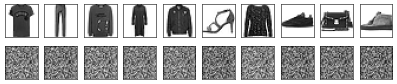

In [7]:
plot_digits()

at epoch 0 toal loss = 604385.9473266602


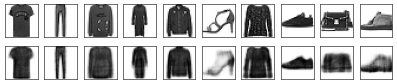

at epoch 10 toal loss = 517735.25762939453


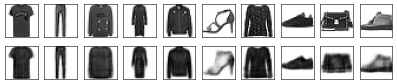

at epoch 20 toal loss = 490563.0123901367


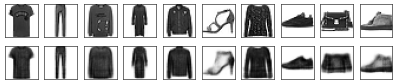

at epoch 30 toal loss = 475855.21253967285


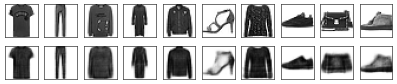

at epoch 40 toal loss = 466152.04919433594


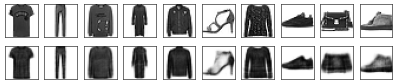

at epoch 50 toal loss = 459246.87480163574


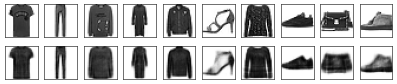

at epoch 60 toal loss = 453992.9123535156


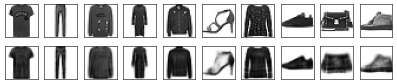

at epoch 70 toal loss = 449674.41690063477


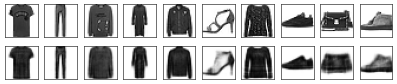

at epoch 80 toal loss = 446105.8861999512


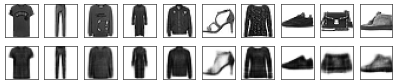

at epoch 90 toal loss = 443203.64710998535


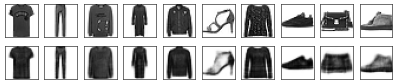

at epoch 100 toal loss = 440677.2212371826


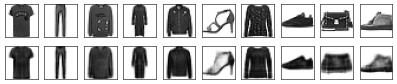

In [9]:
for epoch in range(101):
    tloss=0
    for imgs, labels in train_loader:
        # reconstruct the images
        imgs=imgs.to(device).view(-1, input_dim)
        out, mu=model(imgs)
        # reconstruction loss (MSE)
        loss=((out-imgs)**2).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tloss+=loss.item()
    if epoch%10==0:
        print(f"at epoch {epoch} toal loss = {tloss}")
        # visualize the reconstructed digits
        plot_digits()

In [10]:
# Export to TorchScript
scripted = torch.jit.script(model) 
# Save the model
scripted.save('results/AEdigits.pt') 

In [11]:
model=torch.jit.load('results/AEdigits.pt',map_location=device)
model.eval()

RecursiveScriptModule(
  original_name=AE
  (common): RecursiveScriptModule(original_name=Linear)
  (encoded): RecursiveScriptModule(original_name=Linear)
  (l1): RecursiveScriptModule(original_name=Linear)
  (decode): RecursiveScriptModule(original_name=Linear)
)

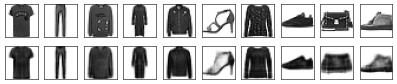

In [12]:
plot_digits()